# 01 - EDA (Analisis Exploratorio de Datos)

Este notebook analiza el dataset `train.csv` del reto de prediccion de precios de vivienda.

Objetivos:
- Entender la estructura del dataset.
- Analizar variable objetivo (`SalePrice`).
- Detectar nulos y posibles outliers.
- Revisar correlaciones entre variables numericas.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style="whitegrid")

DATA_PATH = Path("../data/train.csv")
df = pd.read_csv(DATA_PATH)

print(f"Shape del dataset: {df.shape}")
df.head()

Shape del dataset: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Informacion general y estadisticos basicos

df.info()
df.describe().T.head(15)

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


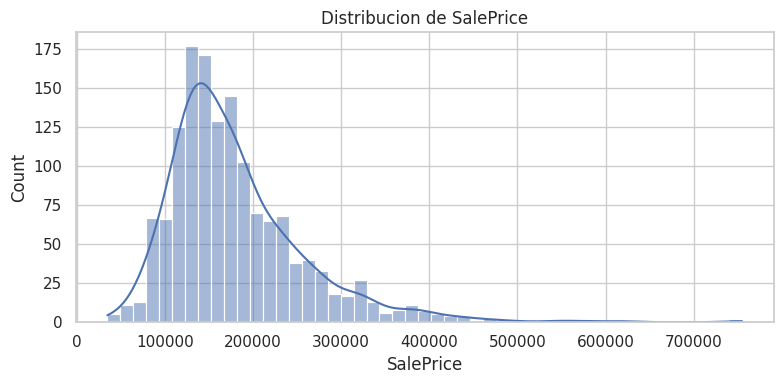

Media SalePrice: 180921.2
Mediana SalePrice: 163000.0


In [ ]:
# Analisis de la variable objetivo: SalePrice

plt.figure(figsize=(8, 4))
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribucion de SalePrice")
plt.xlabel("SalePrice")
plt.tight_layout()
plt.show()

print("Media SalePrice:", round(df["SalePrice"].mean(), 2))
print("Mediana SalePrice:", round(df["SalePrice"].median(), 2))

In [ ]:
# Nulos: top 15 columnas con mas valores faltantes

nulls = df.isnull().sum().sort_values(ascending=False)
nulls = nulls[nulls > 0]
nulls.head(15).to_frame("missing_values")

,missing_values
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


In [ ]:
# Correlaciones con SalePrice (solo numericas)

corr = df.corr(numeric_only=True)

saleprice_corr = (
    corr["SalePrice"]
    .drop("SalePrice")
    .sort_values(ascending=False)
)

print("Top 10 correlaciones positivas con SalePrice")
display(saleprice_corr.head(10).to_frame("corr_with_saleprice"))

print("Top 10 correlaciones negativas con SalePrice")
display(saleprice_corr.tail(10).to_frame("corr_with_saleprice"))

Top 10 correlaciones positivas con SalePrice


,corr_with_saleprice
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101


Top 10 correlaciones negativas con SalePrice


,corr_with_saleprice
BsmtFinSF2,-0.011378
BsmtHalfBath,-0.016844
MiscVal,-0.021190
Id,-0.021917
LowQualFinSF,-0.025606
YrSold,-0.028923
OverallCond,-0.077856
MSSubClass,-0.084284
EnclosedPorch,-0.128578
KitchenAbvGr,-0.135907


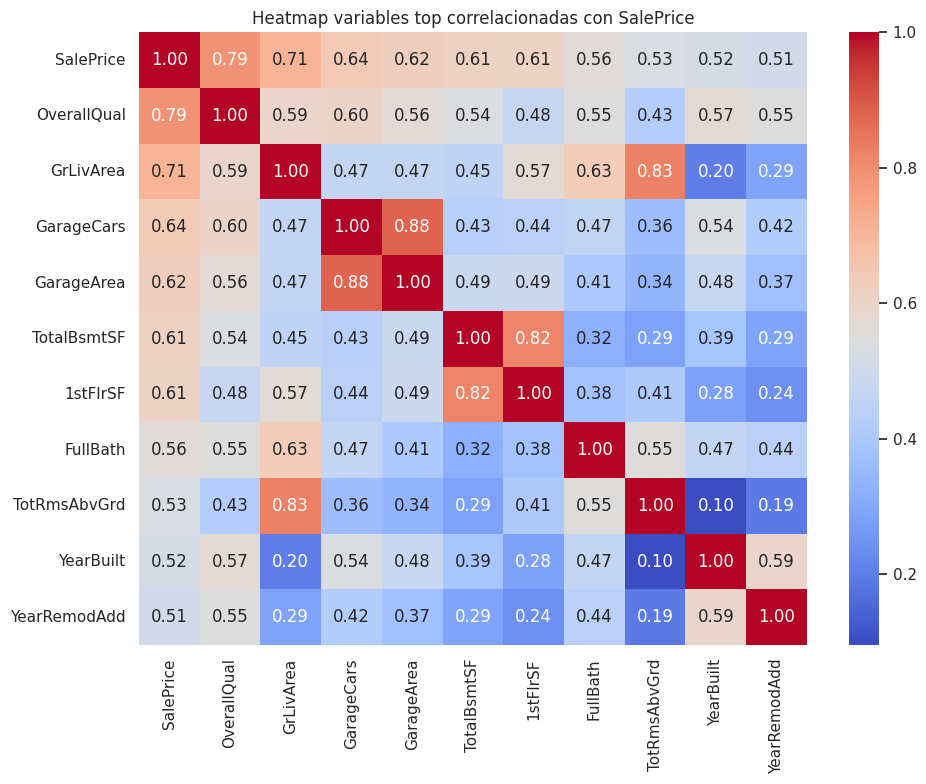

In [ ]:
# Heatmap de correlaciones de variables mas relacionadas con SalePrice

top_features = ["SalePrice"] + saleprice_corr.head(10).index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features].corr(numeric_only=True), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Heatmap variables top correlacionadas con SalePrice")
plt.tight_layout()
plt.show()

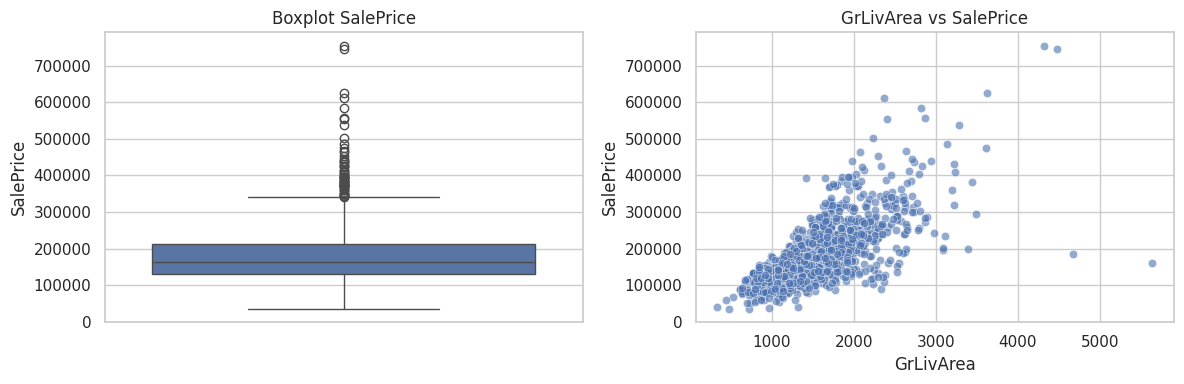

In [ ]:
# Outliers visuales: SalePrice y GrLivArea

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=df["SalePrice"], ax=axes[0])
axes[0].set_title("Boxplot SalePrice")

sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"], ax=axes[1], alpha=0.6)
axes[1].set_title("GrLivArea vs SalePrice")

plt.tight_layout()
plt.show()

## Conclusiones rapidas EDA

- El dataset tiene suficiente tamano para el reto (1460 filas).
- `SalePrice` presenta sesgo a la derecha.
- Hay columnas con nulos relevantes que requeriran imputacion.
- `OverallQual`, `GrLivArea`, `GarageCars` y `TotalBsmtSF` muestran alta relacion con `SalePrice`.
- Existen outliers, especialmente en superficies altas y precios extremos.